In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
train=pd.read_csv("C:/Users/HP/Downloads/cleaned hotel booking datasets/Hotel_A_Train_Cleaned (4).csv")

In [5]:
val=pd.read_csv("C:/Users/HP/Downloads/cleaned hotel booking datasets/Hotel_A_Validation_Cleaned (3).csv")

In [7]:
# list of columns that are NOT useful for the mathematical model
cols_to_drop = ['Reservation-id', 'Expected_checkin', 'Expected_checkout', 'Booking_date']

# Prepare X (Features) and y (Target)
X_train = train.drop(columns=cols_to_drop + ['Reservation_Status'], errors='ignore')
y_train = train['Reservation_Status']

X_val = val.drop(columns=cols_to_drop + ['Reservation_Status'], errors='ignore')
y_val = val['Reservation_Status']

print(f"Training features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")

Training features shape: (26989, 33)
Validation features shape: (2733, 33)


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data using a scaler
X_val_scaled = scaler.transform(X_val)


# Converting back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)


print("Scaling complete")

Scaling complete


In [10]:
# changing variables to start from 0
y_train_shifted = y_train - 1
y_val_shifted = y_val - 1

##Automated Feature Selection

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Top 15 features
selector = RandomForestClassifier(n_estimators=100, random_state=42)
selector.fit(X_train_scaled, y_train_shifted)

# Get the indices of the top 15 features
importances = selector.feature_importances_
indices = np.argsort(importances)[::-1][:15]
top_features = X_train_scaled.columns[indices].tolist()

# Filter scaled data to only above features
X_train_final = X_train_scaled[top_features]
X_val_final = X_val_scaled[top_features]


print("Top 15 Features Selected:", top_features)

Top 15 Features Selected: ['Lead_Time', 'Room_Rate', 'Age', 'Checkin_Month', 'Total_Guests', 'Discount_Rate', 'Length_of_Stay', 'Meal_Type_fb', 'Gender_m', 'Required_Car_Parking_yes', 'Country_region_south', 'Hotel_Type_city hotel', 'Booking_channel_online', 'Visted_Previously_yes', 'Income_50k -- 100k']


In [12]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.3 MB/s eta 0:01:19
   ---------------------------------------- 0.8/101.7 MB 1.4 MB/s eta 0:01:13
    --------------------------------------- 1.3/101.7 MB 1.5 MB/s eta 0:01:08
    --------------------------------------- 1.6/101.7 MB 1.5 MB/s eta 0:01:06
    --------------------------------------- 2.1/101.7 MB 1.6 MB/s eta 0:01:02
    --------------------------------------- 2.4/101.7 MB 1.6 MB/s eta 0:01:02
   - -------------------------------------- 2.6/101.7 MB 1.5 MB/s eta 0:01:06
   - -------------------------------------- 2.9/101.7 MB 1.5 MB/s eta 0:01:05
   - -------------------------------------- 3.1/101.7 MB 1.6 MB/s eta 0:01:04
   - -------------------------------------- 3.4/101.7 MB 1.5 MB/s eta 0:01:07
   - --

In [16]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Defining the base model
xgb = XGBClassifier(
    objective='multi:softprob',
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Parameters to test
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Try 10 different combinations
xgb_search = RandomizedSearchCV(
    xgb, param_distributions=param_dist,
    n_iter=10, cv=3, verbose=1, n_jobs=-1, random_state=42
)

xgb_search.fit(X_train_final, y_train_shifted)

#Getting best parameters
best_xgb = xgb_search.best_estimator_
print(f"Best Parameters Found: {xgb_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\HP\OneDrive\anaconda\envs\DataScience\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:04:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters Found: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


Initial model  without weights

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict
y_pred_shifted = best_xgb.predict(X_val_final)

# Shift back to original labels for the report
y_pred_original = y_pred_shifted + 1
y_val_original = y_val_shifted + 1

print("\n--- XGBoost Final Evaluation ---")
print(classification_report(y_val_original, y_pred_original))



--- XGBoost Final Evaluation ---
              precision    recall  f1-score   support

           1       0.59      1.00      0.74      1602
           2       0.00      0.00      0.00       738
           3       0.00      0.00      0.00       393

    accuracy                           0.59      2733
   macro avg       0.20      0.33      0.25      2733
weighted avg       0.34      0.59      0.43      2733



c:\Users\HP\OneDrive\anaconda\envs\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\OneDrive\anaconda\envs\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\OneDrive\anaconda\envs\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [18]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
acc = accuracy_score(y_val_original, y_pred_original)

print(f"Overall Accuracy: {acc:.2%}")

Overall Accuracy: 58.62%


Model with assumed manual weights

In [19]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import classification_report
import re # Import re for the clean_header function

y_train_xgb = y_train - 1
y_val_xgb = y_val - 1

# Adding weights for the 3 classes (Check-in, Canceled, No-show)
weights_dict = {0: 1, 1: 4, 2: 8} # Giving more weight to No-shows
sample_weights = np.array([weights_dict[y] for y in y_train_xgb])

# Define the clean_header function here to ensure it's available
def clean_header(df):
    # Replacing column names with odd symbols
    df.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', str(col)) for col in df.columns]
    df.columns = [re.sub(r'__+', '_', col) for col in df.columns]
    return df

# Applying the cleaning to the scaled dataframes
X_train_scaled = clean_header(X_train_scaled)
X_val_scaled = clean_header(X_val_scaled)

#Initializing the model
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softprob',
    random_state=42
)

#Fit the model using the sample weights
xgb_model.fit(X_train_scaled, y_train_xgb, sample_weight=sample_weights)

#Prediction and evaluatation
y_pred = xgb_model.predict(X_val_scaled)
print(classification_report(y_val_xgb, y_pred, target_names=['Check-in', 'Canceled', 'No-show']))

              precision    recall  f1-score   support

    Check-in       0.60      0.57      0.58      1602
    Canceled       0.28      0.24      0.26       738
     No-show       0.15      0.22      0.18       393

    accuracy                           0.43      2733
   macro avg       0.34      0.34      0.34      2733
weighted avg       0.45      0.43      0.44      2733



Model with Calculated Pure weights

In [21]:
import pandas as pd
import numpy as np
import xgboost as xgb
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight


y_train_xgb = y_train.fillna(1).astype(int) - 1
y_val_xgb = y_val.astype(int) - 1

# Calculating exactly n_samples / (n_classes * n_samples_j) for weights
classes = np.unique(y_train_xgb)
calculated_weights = compute_class_weight(class_weight='balanced',
                                          classes=classes,
                                          y=y_train_xgb)

weights_dict = dict(zip(classes, calculated_weights))
print(f"Weights from formula: {weights_dict}")

# Mapping to every row
sample_weights = np.array([weights_dict[y] for y in y_train_xgb])

X_train.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', str(c)) for c in X_train.columns]
X_val.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', str(c)) for c in X_val.columns]

# Scaling the data
scaler = StandardScaler()
X_train_final = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_final = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)

# Initializing the model
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softprob',
    random_state=42
)

xgb_model.fit(X_train_final, y_train_xgb, sample_weight=sample_weights)

# Prediction and Evaluation
y_pred = xgb_model.predict(X_val_final)
print(classification_report(y_val_xgb, y_pred, target_names=['Check-in', 'Canceled', 'No-show']))

Weights from formula: {np.int64(0): np.float64(0.43305734732518214), np.int64(1): np.float64(2.189954560207725), np.int64(2): np.float64(4.269735801297263)}
              precision    recall  f1-score   support

    Check-in       0.59      0.46      0.52      1602
    Canceled       0.29      0.32      0.30       738
     No-show       0.15      0.25      0.19       393

    accuracy                           0.39      2733
   macro avg       0.34      0.34      0.33      2733
weighted avg       0.45      0.39      0.41      2733



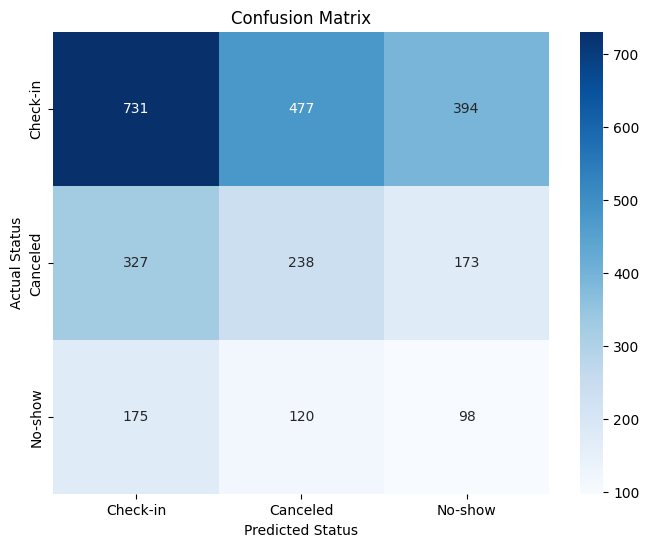

In [22]:
# Plotting a confusion matrix to understand where the model is getting confused
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val_xgb, y_pred)
labels = ['Check-in', 'Canceled', 'No-show']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix')
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.show()